In [82]:
# importing the stuff i need
# pandas = for reading the csv and tables
# matplotlib = for making charts
# SentimentIntensityAnalyzer = a tool that guesses if text is happy or angry

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [83]:

df = pd.read_csv('dataset_google-play-reviews-scraper_2026-07-17_05-12-57-833.csv')
df = df[['text','score','user_name']]
df.columns

Index(['text', 'score', 'user_name'], dtype='str')

In [84]:
df.shape

(1000, 3)

In [85]:
#cleanig ds
df = df.dropna(subset=['text'])
df = df.drop_duplicates(subset=['text'])
df = df.reset_index(drop=True)
df.shape

(887, 3)

In [86]:
#starts count
df['score'].value_counts().sort_index()

score
1    558
2     41
3     33
4     35
5    220
Name: count, dtype: int64

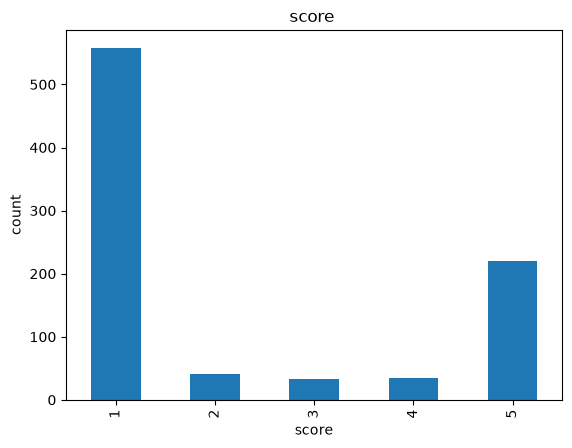

In [87]:
#data vizualisation
df['score'].value_counts().sort_index().plot(kind='bar')

plt.title("score ")
plt.xlabel("score")
plt.ylabel("count")
plt.show()



In [88]:
#sentiment analysis
analyzer = SentimentIntensityAnalyzer()
df["sentiment_scores"] = df["text"].apply(
    lambda x: analyzer.polarity_scores(str(x))
)

In [89]:
def get_score(text):
    result = analyzer.polarity_scores(text)
    return result['compound']  #compound = the overall score

df['sentiment_score'] = df['text'].apply(get_score)
df[['text', 'sentiment_score']].head(10)

,text,sentiment_score
0,good,0.4404
1,Best wallet app in nepal,0.6369
2,i was at shop buying 60 rs item but i cant pay because we must transfer 100+ what a useless app,-0.5033
3,very very bad communication and worst service. Pathetic,-0.9165
4,totally worthless customer help and support,0.3550
5,so disgusting app they just scam me. i suggest you guys to use esewa it is much more better then this faltu app,-0.6369
6,Otp didn't get but blocked for some minutes when I linked my Bank,0.3007
7,"I have been using this app for the past 8 years, and it has been very useful. It is easy to use, reliable, and has helped me in many ways. I highly recommend it to anyone looking for a helpful app. Definitely deserves a 5-star rating!",0.9284
8,Smooth with payments. Only app in Nepal for seamless payment experience.,0.0000
9,wow.,0.5859


In [90]:
#turing score into +ve _ve and deutral
def label_it(score):
    if score >= 0.33:
        return "Positive"
    elif score <= -0.33:
        return "Negative"
    else:
        return "Neutral"

df['feeling'] = df['sentiment_score'].apply(label_it)


df['feeling'].value_counts()

feeling
Neutral     322
Negative    310
Positive    255
Name: count, dtype: int64

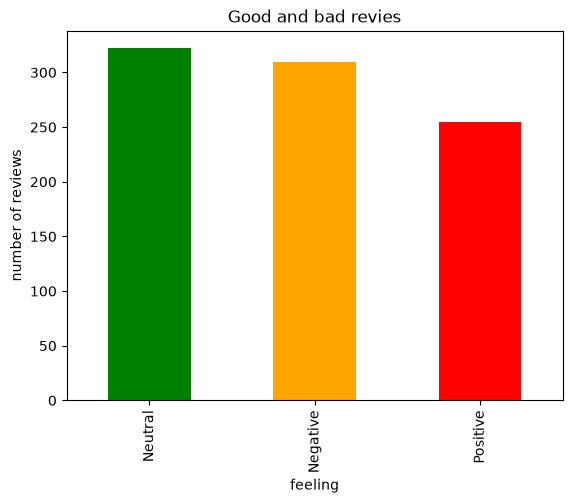

In [91]:
# bar chart 
df['feeling'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])

plt.title("Good and bad revies")
plt.xlabel("feeling")
plt.ylabel("number of reviews")
plt.show()

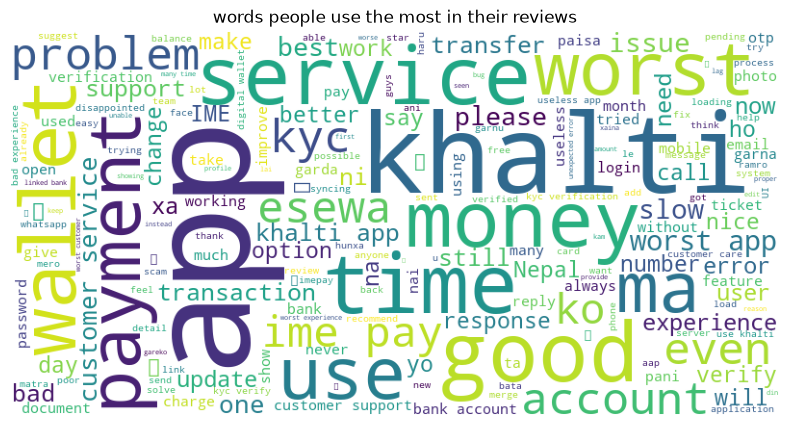

In [100]:
#word cloud
all_the_words = " ".join(df['text'])

cloud = WordCloud(width=800, height=400, background_color="white").generate(all_the_words)

plt.figure(figsize=(10,5))
plt.imshow(cloud)
plt.axis("off")  # dont need the x/y numbers for a picture
plt.title("words people use the most in their reviews")
plt.show()

In [ ]:
#top revies
top_reviews = df.sort_values('score', ascending=True)
top_reviews[['text', 'score', 'feeling']].head(5)

In [ ]:
pd.set_option('display.max_colwidth', None)
df.loc[812, "text"]

In [93]:
print(len(df))
print(df.index.max())

887
886


In [94]:
top_negative = df.sort_values('feeling', ascending=True)
top_negative[['text', 'score', 'feeling']].head(10)

,text,score,feeling
433,I could not find the game of this game version of Khalti app.now not run app why?? Kyc edit गर्नुपर्ने तर edit hudain किन होला त्यो पनि बनाउनुपर्ने अवस्था छ. App update garda ni Kyc edit option xaen Kyc updates wa edit options चाहियो.kyc edit hudain option xaen.yo complain mahino ma pani solved hudain kina??? Home pages ma bugs xa check garnu hola.jati complain garda pani hernu hudain kin hola???? update option xaen.,5,Negative
559,They destroy imepay and their own legacy after merged.,1,Negative
224,यो खल्तीले मैले link payment गर्दाखेरि payment failed भएको पैसा दुई महिना हुँदाखेरि पनि हाल्दिँदैन,5,Negative
829,"Here is the report on the accessibility of IME Pay for blind users, including the issues and suggested improvements: ​Report: Enhancing Accessibility of IME Pay for Blind Users ​Introduction: IME Pay, a widely used mobile wallet in Nepal, currently presents significant accessibility barriers for blind users. This report outlines the specific challenges encountered and provides actionable recommendations to improve the user experience for visually impaired individuals. ​Current Accessibility Issu",3,Negative
221,Khattam wallet of Nepal... Euta KYC verify grna ni mahinau samma kurnu prne. No customer support...,1,Negative
220,one of the worst costumer services I've ever faced. ive waited 5 months for a simple thing as to change my phone number. esewa did it in 12 hrs. ive sent 10 emails. called them more than 10 times. they said me to wait for 24 hrs and its been 72 hrs but still nothing. i do not recommend this service to anyone. i have my money stuck in their account for more than 5 months which im not being able to use. you guys suck. shame on you.👎👎👎👎👎👎,1,Negative
219,Zero star Dina man thyo milne rainaxa.Worst wallet with worst customer care staff. Nata account close garera Naya verify garna dinxa nata account merge nai . Useless staff haru mail ma aaijo vanxa Ani response ni didai na.,1,Negative
830,This app is really bad. I deposited money in Smart Deposit a few days ago but it shows as missed and pending.,1,Negative
558,STOP SENDING NOTIFICATIONS EVERY 5 MINUTES.,1,Negative
217,Khalti vanne company ko costumer service is very worst aaja thaa paye. Mailr khalti pasal darta garera chalayeko xu. Aaja yeuta transaction pending ma basyo. 5 ghanta vayo costumer service ma follow up gareko. Ek ta call uthdaina arko uthe pani kei kaam gardaina. Worst service 😡 yo rating 1 pani na garna na milne banauna milxa hola ni hai.,1,Negative
